## Polynomial Regression Evaluation

Polynomial regression is a more efficient method in comparison Linear regression, as it is able to identify and configure a more specified trend. 

In [6]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pickle

In [7]:
filename = "polynomial_model.sav"
model_A = pickle.load(open(filename, 'rb'))

In [8]:
# Assign testing data to a variable
testing_data = pd.read_csv("2.4.1.testing_data.csv")

# Define different x columns for each model
x_cols = ["k/d", "matchs_played"]
y_col = "win%"

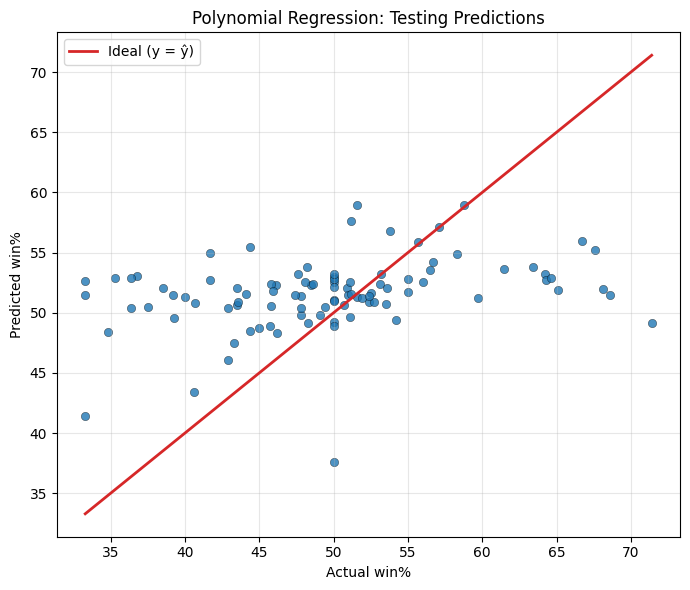

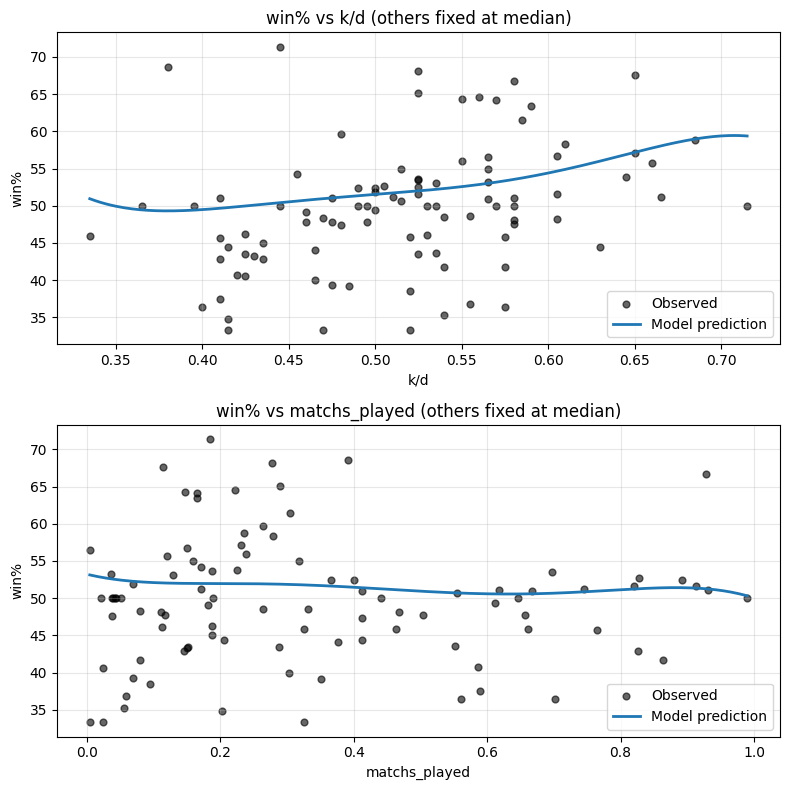

In [ ]:
# Evaluate model on testing data + plots (supports 1 or many x_cols)

if isinstance(x_cols, str):
    x_cols = [x_cols]

missing_cols = [c for c in x_cols + [y_col] if c not in testing_data.columns]
if missing_cols:
    raise ValueError(f"Missing columns in testing_data: {missing_cols}")

eval_df = testing_data[x_cols + [y_col]].dropna()
X_test = eval_df[x_cols].to_numpy(dtype=float)
y_test = eval_df[y_col].to_numpy(dtype=float)

# Predictions
y_pred = model_A.predict(X_test)

# Plot 1: Actual vs Predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.8, color="tab:blue", edgecolor="k", linewidth=0.3)
lo, hi = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([lo, hi], [lo, hi], color="tab:red", linewidth=2, label="Ideal (y = ŷ)")
plt.title("Polynomial Regression: Testing Predictions")
plt.xlabel(f"Actual {y_col}")
plt.ylabel(f"Predicted {y_col}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: One panel per feature (works for one or many features)
n_features = X_test.shape[1]
fig, axes = plt.subplots(
    nrows=n_features, ncols=1, figsize=(8, 4 * n_features), squeeze=False
)

x_ref = np.median(X_test, axis=0)  # hold other features constant

for i in range(n_features):
    ax = axes[i, 0]
    ax.scatter(X_test[:, i], y_test, s=24, alpha=0.6, color="black", label="Observed")

    x_i = X_test[:, i]
    x_grid = np.linspace(x_i.min(), x_i.max(), 250)
    x_plot = np.tile(x_ref, (len(x_grid), 1))
    x_plot[:, i] = x_grid

    y_grid_pred = model_A.predict(x_plot)
    ax.plot(
        x_grid, y_grid_pred, color="tab:blue", linewidth=2, label="Model prediction"
    )

    ax.set_title(f"{y_col} vs {x_cols[i]} (others fixed at median)")
    ax.set_xlabel(x_cols[i])
    ax.set_ylabel(y_col)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Predictions
y_pred = model_A.predict(X_test)

# Metrics
m = len(y_test)
sse = np.sum((y_test - y_pred) ** 2)
average_cost = sse / (2 * m)  # J = (1/2m) * Σ(y - ŷ)^2
mse = mean_squared_error(y_test, y_pred)
ae = mean_absolute_error(y_test, y_pred)  # MAE
model_score = model_A.score(X_test, y_test)  # R^2

print(f"Average cost (J): {average_cost:.6f}")
print(f"MSE: {mse:.6f}")
print(f"AE (MAE): {ae:.6f}")
print(f"Model score (R^2): {model_score:.6f}")

Average cost (J): 33.483210
MSE: 66.966420
AE (MAE): 6.148309
Model score (R^2): 0.051838
